In [616]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [617]:
df = pd.read_csv("Credit_Card_Customer_Data.csv");

In [618]:
df.head(10)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
5,6,58634,20000,3,0,1,8
6,7,48370,100000,5,0,11,2
7,8,37376,15000,3,0,1,1
8,9,82490,5000,2,0,2,2
9,10,44770,3000,4,0,1,7


In [619]:
# After analyzing the data (excel) there appears to be no missing values, save possibly a few zeroes. 
# These zeroes, however, appear to be legitimate values. Ther person just probably didn't need go to the bank, etc.

In [620]:
#Identify duplicate records in the data
duplicates = df.duplicated()
sum(dupes)

0

In [621]:
# The 5 number summary
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [622]:
df.shape

(660, 7)

In [623]:
df.dtypes

Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object

In [624]:
df.isnull().values.any()

False

In [625]:
# No missing values whatsoever, moving on.

# EDA

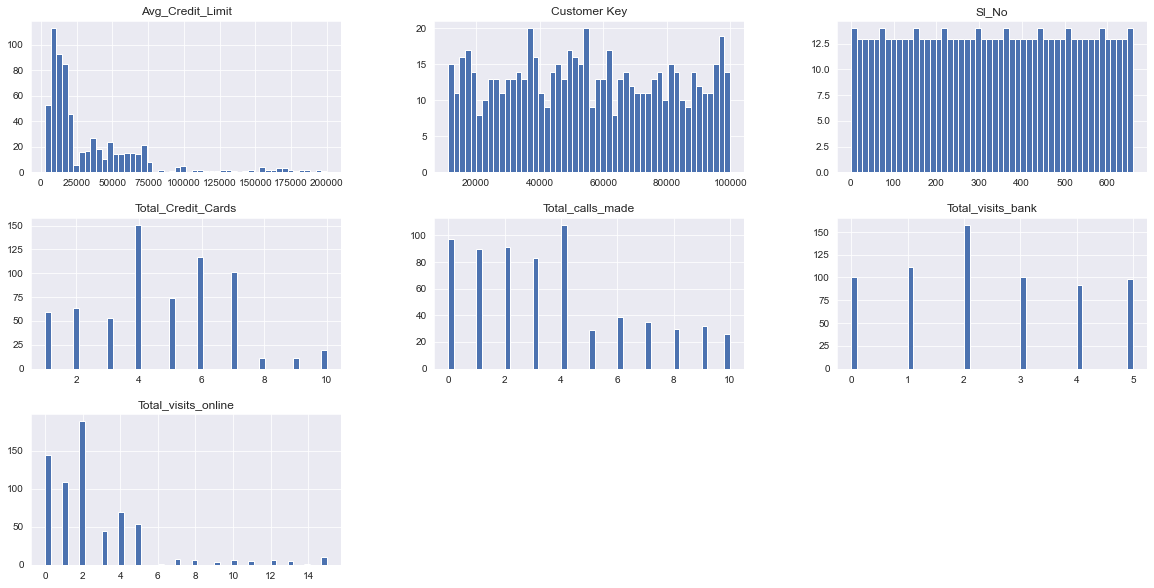

In [626]:
#Univariate analysis
df.hist(figsize=(20,10), bins=50);

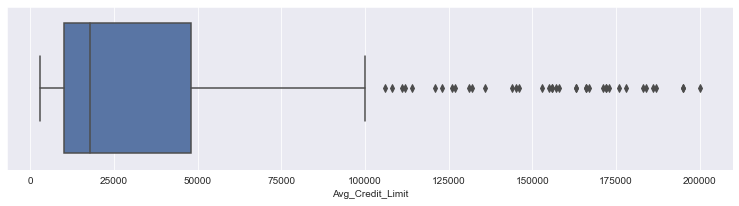

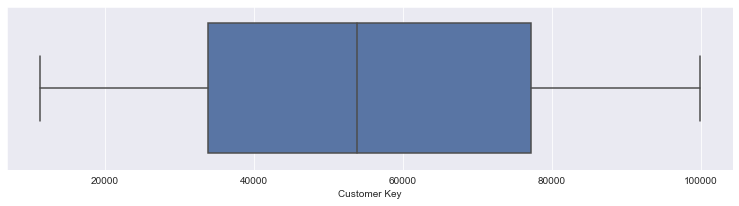

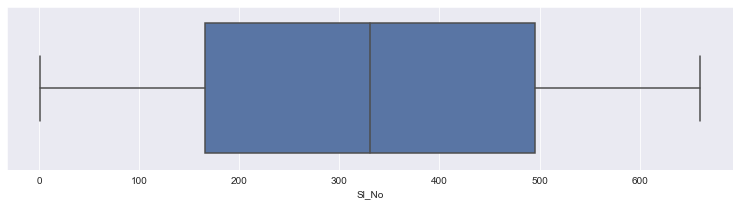

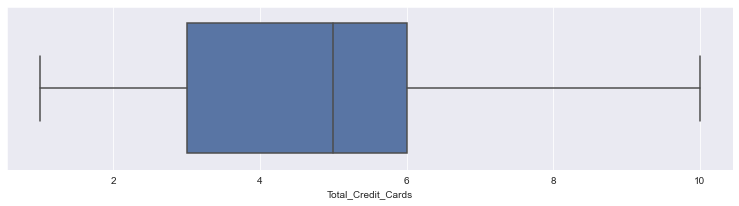

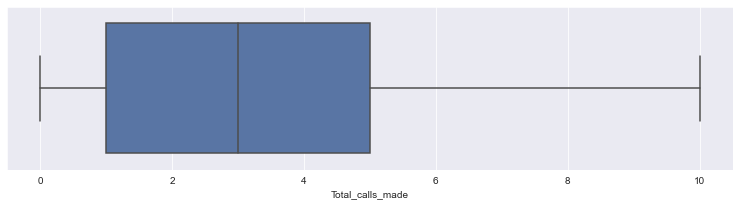

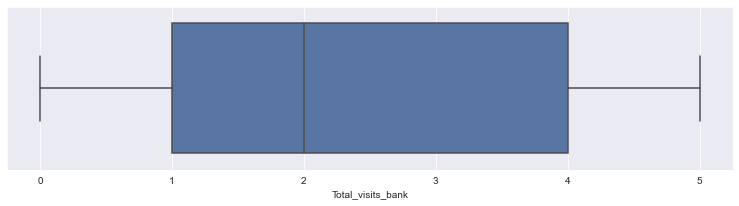

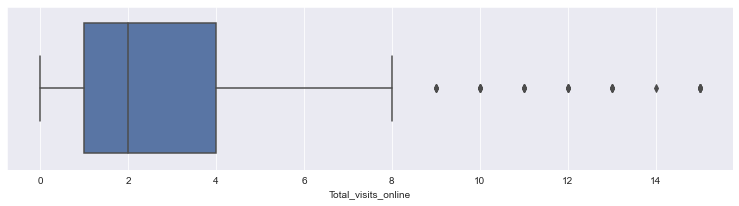

In [530]:
# Outlier detection, Univariate Boxplots
sns.set({'figure.figsize': (13,3)})
def box_plot(frame):
    for i in ['Avg_Credit_Limit', 'Customer Key', 'Sl_No', 'Total_Credit_Cards', 'Total_calls_made', 'Total_visits_bank', 'Total_visits_online']:
        sns.boxplot(df[i])
        plt.show()
            
box_plot(df)

In [627]:
# Removing outliers
# IQR:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
IQR

Sl_No                    329.50
Customer Key           43377.25
Avg_Credit_Limit       38000.00
Total_Credit_Cards         3.00
Total_visits_bank          3.00
Total_visits_online        3.00
Total_calls_made           4.00
dtype: float64

In [628]:
# Using IQR:
np.set_printoptions(threshold = np.inf) # To prevent from the array truncating in the output.
outliers = np.where((df < (Q1 - 1.5 * IQR)) | (df > (Q1 + 1.5 * IQR)))

for i in outliers:
    print(i)

[  0   1   1   4   4   5   6   6  12  19  24  25  26  27  32  34  36  38
  39  40  45  45  48  50  52  53  54  57  59  61  64  68  74  78  80  80
  88  89  91  98 101 102 104 105 109 111 112 119 121 123 126 127 133 136
 137 138 139 140 142 144 146 148 150 154 157 158 160 163 164 165 168 170
 173 177 181 183 185 187 190 193 195 196 199 200 201 202 205 208 209 213
 214 219 220 222 223 224 226 227 396 400 403 404 406 409 418 421 426 430
 431 435 436 446 453 459 462 466 476 482 499 503 505 518 520 521 523 525
 537 538 539 546 563 565 569 572 574 575 582 587 591 592 600 600 612 612
 612 613 613 613 614 614 614 615 615 615 616 616 616 617 617 617 618 618
 619 619 620 620 620 621 621 621 622 622 622 623 623 623 624 624 625 625
 625 626 626 626 627 627 627 628 628 628 629 629 629 630 630 630 631 631
 631 632 632 633 633 634 634 634 635 635 635 636 636 636 637 637 637 638
 638 638 639 639 640 640 640 640 641 641 641 642 642 642 643 643 643 644
 644 644 645 645 645 646 646 647 647 647 648 648 64

In [629]:
# Percent outliers of data:
outliers_1 = list(outliers[0])

num_outliers = 0
for i in outliers_1:
    num_outliers = num_outliers +1
    
print("Total Outliers: ", num_outliers)

# Percent outliers?
print("Shape of data: ", df.shape)
total_data = (1030 * 9)

print("Total Data: ", total_data)

percent_outliers = (num_outliers/total_data) * 100
print("Percent Outliers: ", percent_outliers)


Total Outliers:  280
Shape of data:  (660, 7)
Total Data:  9270
Percent Outliers:  3.0204962243797198


In [630]:
# Remove outliers
from scipy import stats

df_zscore = df.copy()

df_zscore = np.abs(stats.zscore(df_zscore)) # Give me the zcore of every value in the df in array

threshold = 3
for i, j in zip(np.where(df_zscore > threshold)[0], np.where(df_zscore > threshold)[1]):
    df.iloc[i,j] = df.iloc[:,j].median()

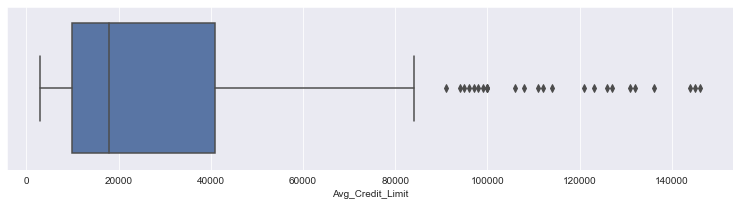

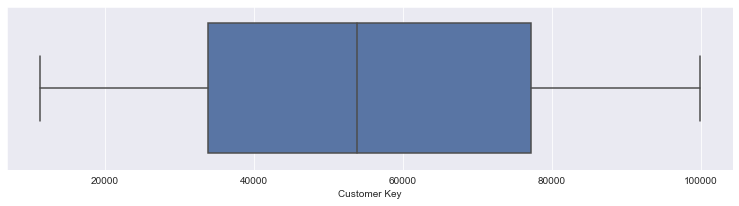

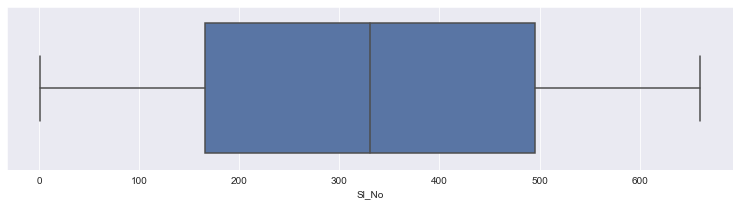

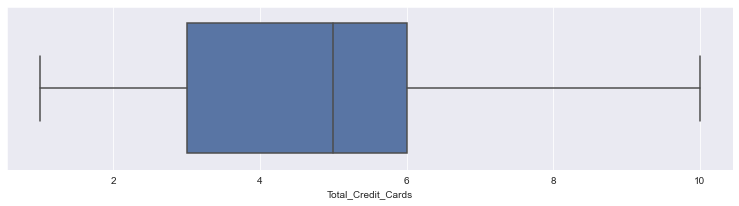

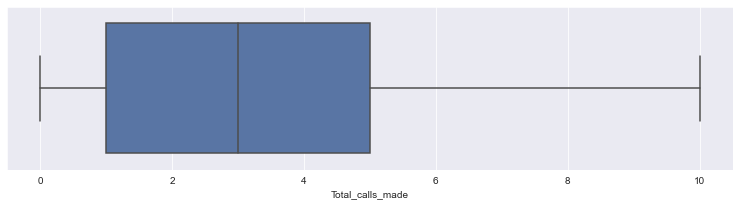

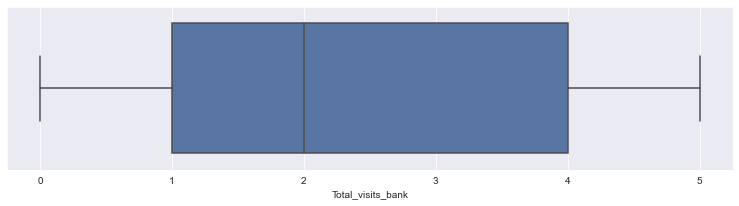

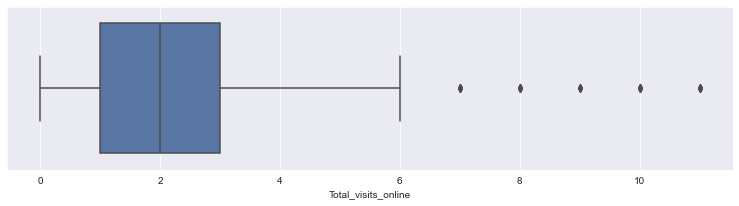

In [631]:
# Show Boxplots again
sns.set({'figure.figsize': (13,3)})
def box_plot(frame):
    for i in ['Avg_Credit_Limit', 'Customer Key', 'Sl_No', 'Total_Credit_Cards', 'Total_calls_made', 'Total_visits_bank', 'Total_visits_online']:
        sns.boxplot(df[i])
        plt.show()
            
box_plot(df)

# Bivariate analysis

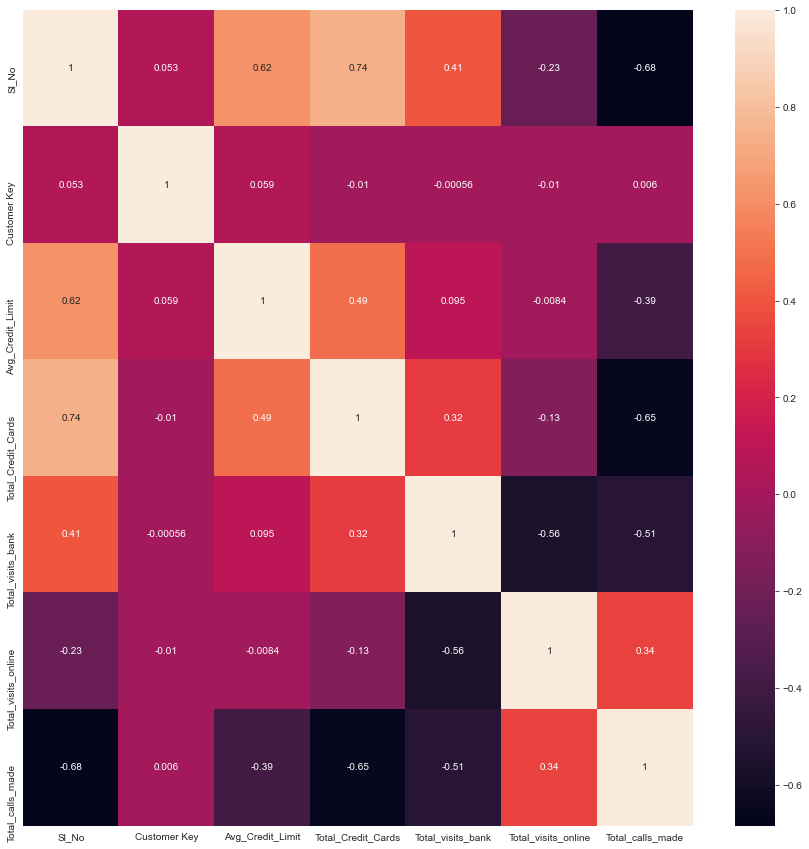

In [123]:
#Heatmap
sns.set({'figure.figsize': (15,15)})
sns.heatmap(df.corr(), annot=True);

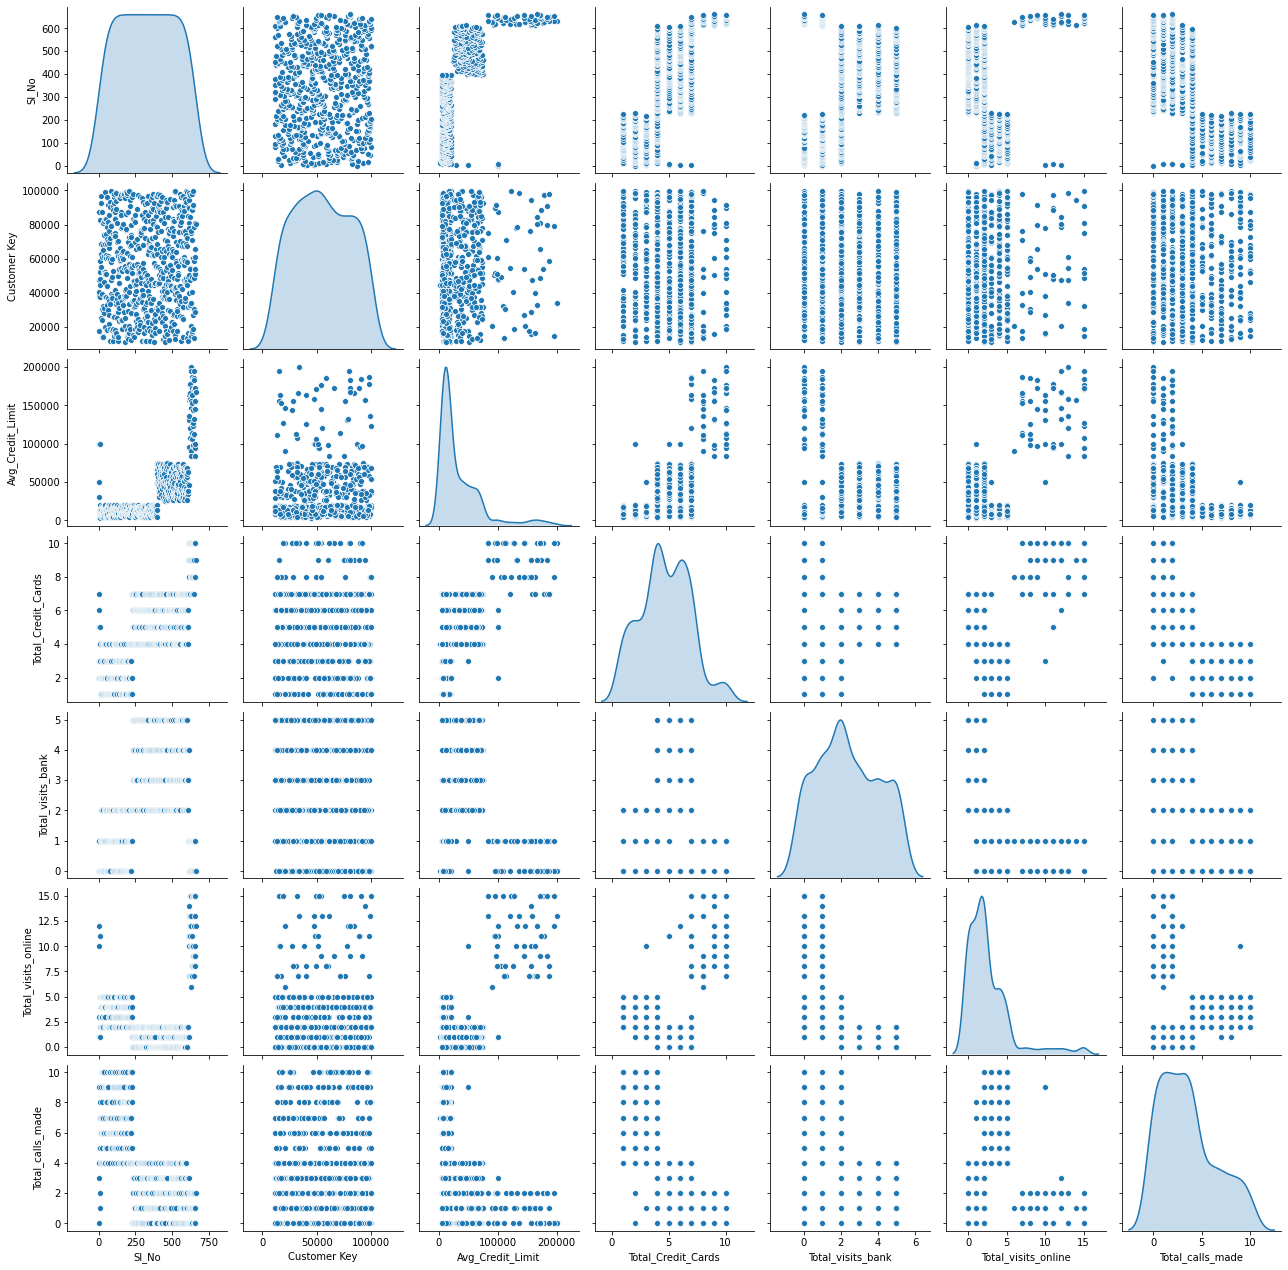

In [12]:
#pairplot
sns.pairplot(df, diag_kind='kde');

In [632]:
# Based on the pairplot above, it seems that there are already groupings emerging
# It appears that there are 3, possibly 4 very pronounced groupings

In [633]:
# Scaling the data

from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()
std_scale

StandardScaler()

In [634]:
df['Sl_No'] = std_scale.fit_transform(df[['Sl_No']])
df['Customer Key'] = std_scale.fit_transform(df[['Customer Key']])
df['Avg_Credit_Limit'] = std_scale.fit_transform(df[['Avg_Credit_Limit']])
df['Total_Credit_Cards'] = std_scale.fit_transform(df[['Total_Credit_Cards']])
df['Total_visits_bank'] = std_scale.fit_transform(df[['Total_visits_bank']])
df['Total_visits_online'] = std_scale.fit_transform(df[['Total_visits_online']])
df['Total_calls_made'] = std_scale.fit_transform(df[['Total_calls_made']])

In [635]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,-1.729428,1.246920,2.690585,-1.249225,-0.860451,-0.585285,-1.251537
1,-1.724180,-0.653203,0.796656,-0.787585,-1.473731,3.744222,1.891859
2,-1.718931,-1.476098,0.796656,1.058973,-0.860451,0.376827,0.145528
3,-1.713683,-0.571901,0.039084,0.135694,-0.860451,-0.585285,0.145528
4,-1.708434,-0.300857,2.690585,0.597334,-1.473731,-0.104229,-0.203739


In [636]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,6.600000e+02,6.600000e+02,6.600000e+02,6.600000e+02,6.600000e+02,6.600000e+02,6.600000e+02
mean,5.853903e-17,4.474535e-17,1.766264e-17,-4.006223e-15,1.157323e-16,-1.268766e-16,-7.112156e-16
std,1.000758e+00,1.000758e+00,1.000758e+00,1.000758e+00,1.000758e+00,1.000758e+00,1.000758e+00
min,-1.729428e+00,-1.713365e+00,-9.836382e-01,-1.710864e+00,-1.473731e+00,-1.066342e+00,-1.251537e+00
25%,-8.647142e-01,-8.323923e-01,-7.184880e-01,-7.875852e-01,-8.604506e-01,-5.852852e-01,-9.022711e-01
50%,0.000000e+00,-4.947386e-02,-4.154593e-01,1.356941e-01,-2.471705e-01,-1.042289e-01,-2.037386e-01
75%,8.647142e-01,8.614790e-01,4.557483e-01,5.973337e-01,9.793898e-01,3.768275e-01,4.947938e-01
max,1.729428e+00,1.745585e+00,4.433001e+00,2.443892e+00,1.592670e+00,4.225278e+00,2.241125e+00


In [637]:
#Appears to have no coorelation whatsoever, so drop
df_model = df.copy()
df_model.drop('Customer Key',axis=1,inplace=True)
#df_model.drop('Total_visits_bank',axis=1,inplace=True)

#These seem to be of little help, so drop
df_model.drop('Total_visits_online',axis=1,inplace=True)
df_model.drop('Total_calls_made',axis=1,inplace=True)
df_model.head()

,Sl_No,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank
0,-1.729428,2.690585,-1.249225,-0.860451
1,-1.724180,0.796656,-0.787585,-1.473731
2,-1.718931,0.796656,1.058973,-0.860451
3,-1.713683,0.039084,0.135694,-0.860451
4,-1.708434,2.690585,0.597334,-1.473731


# Building Models

## K-Means

In [638]:
# It is now time to do clustering
from sklearn.cluster import KMeans

df_KMeans = df_model.copy()

cluster_range = range(1,15)
cluster_errors = []

for num_clusters in cluster_range:
    clusters = KMeans(num_clusters, n_init = 5)
    clusters.fit(df_KMeans)
    labels = clusters.labels_
    centroids = clusters.cluster_centers_
    cluster_errors.append(clusters.inertia_)

clusters_df = pd.DataFrame({"num_clusters": cluster_range, "cluster_errors": cluster_errors})
clusters_df[0:15]

,num_clusters,cluster_errors
0,1,2640.000000
1,2,1401.958263
2,3,987.444270
3,4,758.325750
4,5,608.365317
5,6,530.171241
6,7,460.999829
7,8,413.415698
8,9,385.984236
9,10,358.367789


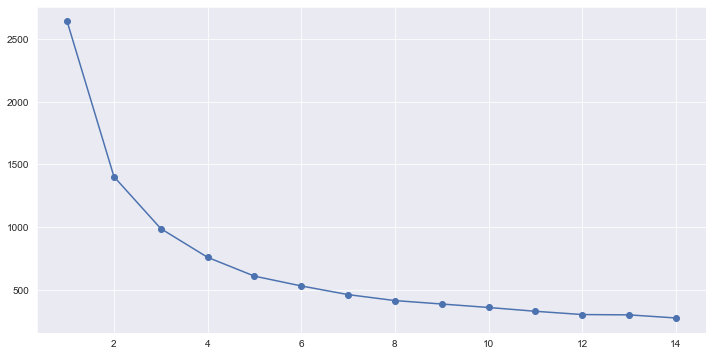

In [639]:
#Elbow method
from matplotlib import cm

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" );

In [640]:
#It seems that the greatest bend(smallest angle in degrees) is at 4 clusters
kmeans = KMeans(n_clusters=4, n_init = 5, random_state=12345)    
#Based on this, we can safely say that 4 is optimal. 
#This was especialy confusing and conflicting, since 11 brings Silhouete score all the way up to 0.69.
#However, we know based on this plot that increasing the clusters so high would be of little value.
kmeans.fit(df_KMeans)

KMeans(n_clusters=4, n_init=5, random_state=12345)

In [ ]:
# Give us the number of data points per cluster
labels = kmeans.labels_
counts = np.bincount(labels[labels>=0])
print(counts)

[235 230  25 170]


In [642]:
# Calculate the centroids
centroids = kmeans.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns = list(df_KMeans) )
centroid_df.transpose()

,0,1,2,3
Sl_No,0.991186,-1.121909,1.475814,-0.063122
Avg_Credit_Limit,0.694837,-0.595959,3.175431,-0.613491
Total_Credit_Cards,0.542095,-1.034462,2.000718,0.357065
Total_visits_bank,0.442114,-0.897781,-1.081231,0.760617


In [643]:
# Let's get the prediction and group numbers
predictions = kmeans.predict(df_KMeans)
predictions

array([1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3,
       3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

In [644]:
df["group"] = predictions
df['group'] = df['group'].astype('category')
df.dtypes

Sl_No                   float64
Customer Key            float64
Avg_Credit_Limit        float64
Total_Credit_Cards      float64
Total_visits_bank       float64
Total_visits_online     float64
Total_calls_made        float64
group                  category
dtype: object

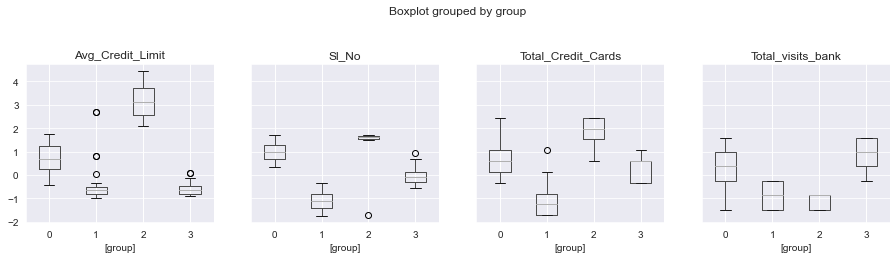

In [645]:
# Visualize with boxplots
df_KMeans["group"] = predictions
df_KMeans.boxplot(by = 'group',  layout=(3,4), figsize=(15, 10));

## Hierarchical clustering

In [651]:
from sklearn.cluster import AgglomerativeClustering 

In [652]:
df_ac = df_model.copy()

In [653]:
ac_model = AgglomerativeClustering(n_clusters=4, affinity='euclidean',  linkage='average')

In [654]:
ac_model.fit(df_ac)

AgglomerativeClustering(linkage='average', n_clusters=4)

In [656]:
df_ac['groups'] = ac_model.labels_
df_ac.head(10)

,Sl_No,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,groups
0,-1.729428,2.690585,-1.249225,-0.860451,2
1,-1.724180,0.796656,-0.787585,-1.473731,1
2,-1.718931,0.796656,1.058973,-0.860451,1
3,-1.713683,0.039084,0.135694,-0.860451,1
4,-1.708434,2.690585,0.597334,-1.473731,2
5,-1.703185,-0.339702,-0.787585,-1.473731,1
6,-1.697937,2.690585,0.135694,-1.473731,2
7,-1.692688,-0.529095,-0.787585,-1.473731,1
8,-1.687439,-0.907881,-1.249225,-1.473731,1
9,-1.682191,-0.983638,-0.325946,-1.473731,1


In [657]:
df_ac.mean()

Sl_No                 5.853903e-17
Avg_Credit_Limit      1.766264e-17
Total_Credit_Cards   -4.006223e-15
Total_visits_bank     1.157323e-16
groups                4.575758e-01
dtype: float64

In [658]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist

In [659]:
#Calculate a few cophnet indexes with dendrograms at different setings

In [665]:
#Cophenet index
Z = linkage(df_ac, metric='euclidean', method='average')
c, coph_dists = cophenet(Z , pdist(df_ac))

c

0.8834161524709068

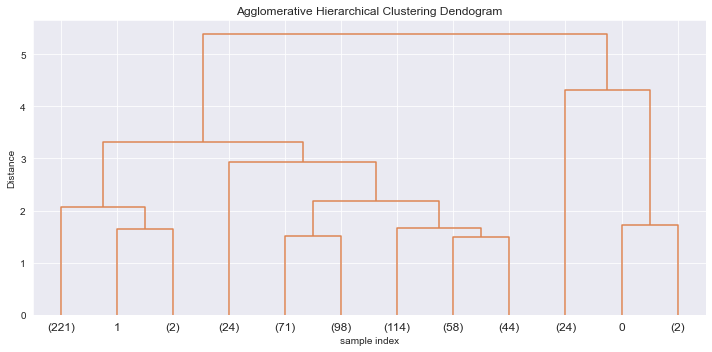

In [666]:
#Dendrogram
plt.figure(figsize=(10, 5))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, truncate_mode='lastp', p=12, # show only the last p merged clusters
           color_threshold = 10, leaf_font_size=12.)
plt.tight_layout()

In [667]:
Z = linkage(df_ac, metric='euclidean', method='ward')
c, coph_dists = cophenet(Z , pdist(df_ac))

print(c)

0.7031094642896171


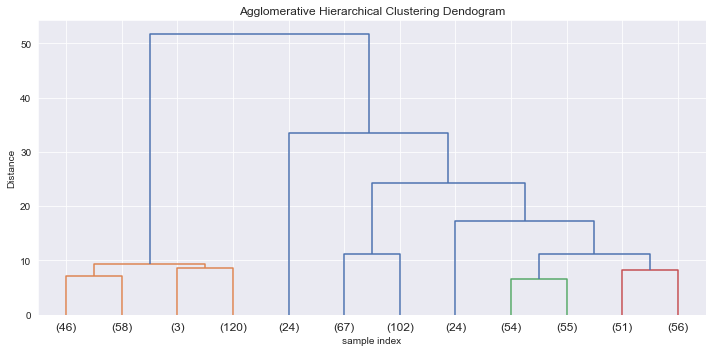

In [668]:
plt.figure(figsize=(10, 5))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, truncate_mode='lastp', p=12, # show only the last p merged clusters
           color_threshold = 10, leaf_font_size=12.)
plt.tight_layout()

In [669]:
Z = linkage(df_ac, metric='euclidean', method='complete')
c, coph_dists = cophenet(Z , pdist(df_ac))

print(c)

0.8473264116687571


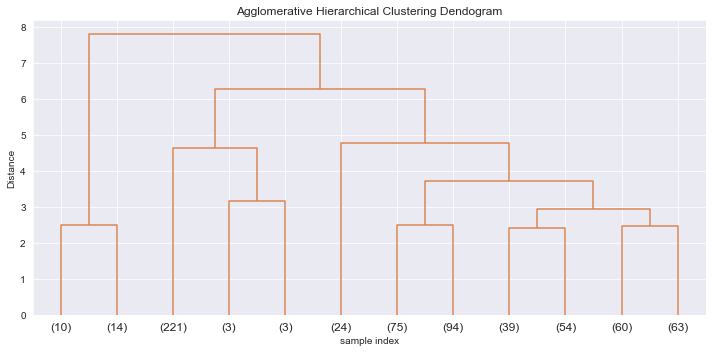

In [671]:
plt.figure(figsize=(10, 5))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, truncate_mode='lastp', p=12, # show only the last p merged clusters
           color_threshold = 10, leaf_font_size=12.)
plt.tight_layout()

# Conclusions

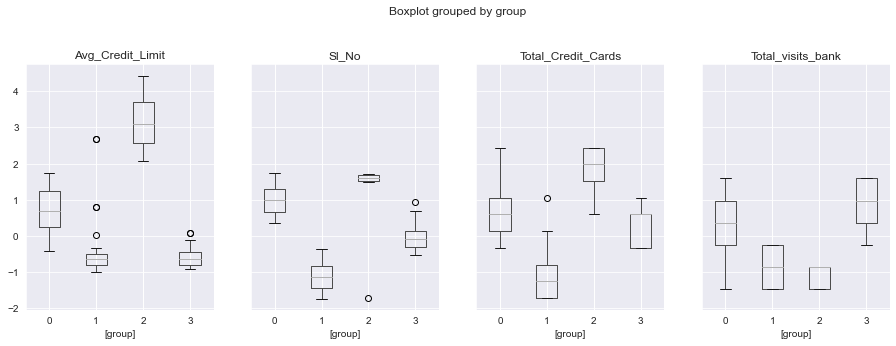

In [681]:
#Boxplots
#K-means
df_KMeans.boxplot(by = 'group',  layout=(2,4), figsize=(15, 10));

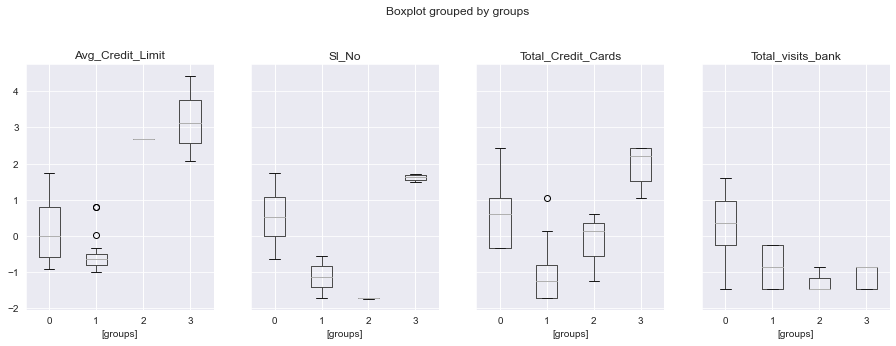

In [680]:
#Agglomerative
df_ac.boxplot(by='groups',  layout=(2,4), figsize=(15, 10));

In [682]:
#Silhouette score
from sklearn.metrics import silhouette_score

#Kmeans
score = silhouette_score(df_KMeans, kmeans.labels_, metric='euclidean')
print('Silhouette Score: %.3f' % score)

Silhouette Score: 0.601


In [683]:
#Agglomerative Clustering
score = silhouette_score(df_ac, ac_model.labels_, metric='euclidean')
print('Silhouette Score: %.3f' % score)

Silhouette Score: 0.509


Similar results can be achieved with either clustering algorithm. However, it looks like K-means did significantly better than hierarchichal clustering. The elbow method line graph was quite interpretive. It appears that optimal results are achieved with 4 clusters.